In [1]:
from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.service import Service as ChromeService
import time
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import Select
from selenium.webdriver.common.keys import Keys

In [2]:
driver = webdriver.Chrome(service=ChromeService(ChromeDriverManager().install()))
driver.get('https://24h.pchome.com.tw/search/?q=%E6%B6%88%E6%AF%92%E9%8D%8B')
time.sleep(1)

In [3]:
rows = []
while True:
    prices = driver.find_elements(By.CSS_SELECTOR, ".c-prodInfoV2__priceValue")
    time.sleep(3)
    for element in prices:
        data = element.text
        row = [data]
        rows = rows + [row]
    element = driver.find_element(By.CSS_SELECTOR, "div.c-pagination__button.is-next")
    element_attr = element.get_attribute("outerHTML")
    if "disabled" in element_attr:
        break
    element.click()
    time.sleep(5)

In [4]:
import pandas as pd
欄位名稱 = ["價格"]
df = pd.DataFrame(rows, columns = 欄位名稱)
df["價格"] = df["價格"].str.replace('$','')
df["價格"] = df["價格"].str.replace(',','')
df.to_csv("./PChome24h_消毒鍋價格_20260426.csv", index=False)

In [5]:
import pandas as pd
df = pd.read_csv("./PChome24h_消毒鍋價格_20260426.csv")
print(df.head())

     價格
0  3399
1  5600
2  1259
3  1999
4  3980


(array([69., 96., 68., 22., 15., 10.,  3.,  3.,  1.,  1.]),
 array([  254. ,  1966.6,  3679.2,  5391.8,  7104.4,  8817. , 10529.6,
        12242.2, 13954.8, 15667.4, 17380. ]),
 <BarContainer object of 10 artists>)

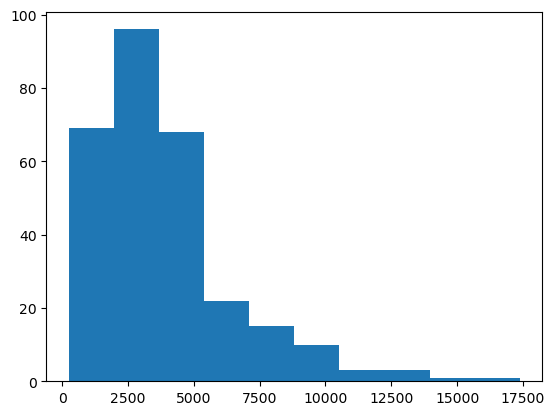

In [6]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot()
ax.hist(df["價格"])